# NEID + iSpec — stellar parameters from coadded spectra

Step 1: **deblaze** NEID L2 using the `SCIBLAZE` profile, convert vacuum→air.
(Written in-notebook first; will be refactored into a helper module once validated.)

In [2]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import importlib, helper; importlib.reload(helper)   # pick up edits without kernel restart
from helper import deblaze_neid, to_rest_frame, clean_and_normalize, coadd_spectra, vac2air, ORD_LO, ORD_HI

BASE_DIR = '/Users/wangxianyu/Program/Github/NEID_iSpec'
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)
L2_FILES = sorted(glob.glob(os.path.join(DATA_DIR, 'neidL2_*.fits')))
ORD_LO, ORD_HI = 45, 82          # NEID echelle orders covering ~480-680 nm
print(f'{len(L2_FILES)} NEID L2 files:')
for f in L2_FILES: print('  ', os.path.basename(f), '->', fits.getheader(f)['OBJECT'])

2 NEID L2 files:
   neidL2_20211027T101436.fits -> XO-3
   neidL2_20211027T102704.fits -> XO-3


38 orders; 476.4-677.4 nm


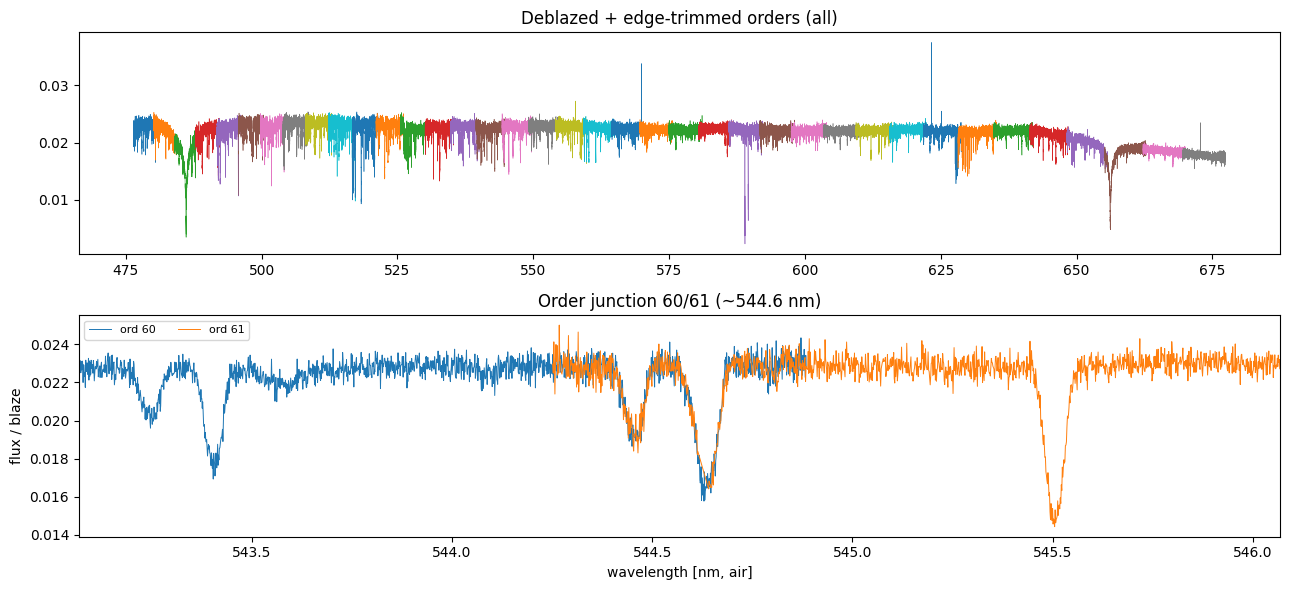

In [3]:
# --- run + visual check (edges trimmed, 77/78 junction stitched) ---
orders = deblaze_neid(L2_FILES[0])
print(f'{len(orders)} orders; {orders[0]["wave_nm"].min():.1f}-{orders[-1]["wave_nm"].max():.1f} nm')

fig, ax = plt.subplots(2, 1, figsize=(13, 6))
allf = np.concatenate([o['flux'] for o in orders])
hi = np.nanpercentile(allf, 99)
for od in orders:
    ax[0].plot(od['wave_nm'], od['flux'], lw=0.4)
# ax[0].set_ylim(0, hi); ax[0].set_ylabel('flux / blaze')
ax[0].set_title('Deblazed + edge-trimmed orders (all)')
# zoom on an order junction chosen by n_junction (lower order of the pair).
# order->wavelength: 45~478, 50~498, 55~519, 60~542, 65~567, 70~595, 75~625, 80~659, 81~666 nm
n_junction = 60          # <-- change to inspect any junction (valid: ORD_LO..ORD_HI-1)
oa = [o for o in orders if o['order'] == n_junction][0]
ob = [o for o in orders if o['order'] == n_junction + 1][0]
wc = 0.5 * (oa['wave_nm'].max() + ob['wave_nm'].min())   # overlap midpoint
w0, w1 = wc - 1.5, wc + 1.5
for od in orders:
    m = (od['wave_nm'] > w0) & (od['wave_nm'] < w1)
    if m.sum() > 10:
        ax[1].plot(od['wave_nm'][m], od['flux'][m], lw=0.7, label=f'ord {od["order"]}')

ax[1].set_xlim(w0, w1); ax[1].set_ylabel('flux / blaze')
ax[1].set_xlabel('wavelength [nm, air]')
ax[1].set_title(f'Order junction {n_junction}/{n_junction+1} (~{wc:.1f} nm)')
ax[1].legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'deblaze_check.png'), dpi=120, bbox_inches='tight'); plt.show()

## Step 2: RV / rest-frame shift (from L2 header, no CCF)

Use the header barycentric redshift (`SSBZ100`) and DRP systemic RV (`QRV`) to shift each exposure to the stellar rest frame analytically.


neidL2_20211027T101436.fits
  BERV = +15.387 km/s, RV_sys = -11.915 km/s -> rest-frame shift +27.303 km/s
neidL2_20211027T102704.fits
  BERV = +15.374 km/s, RV_sys = -11.915 km/s -> rest-frame shift +27.290 km/s


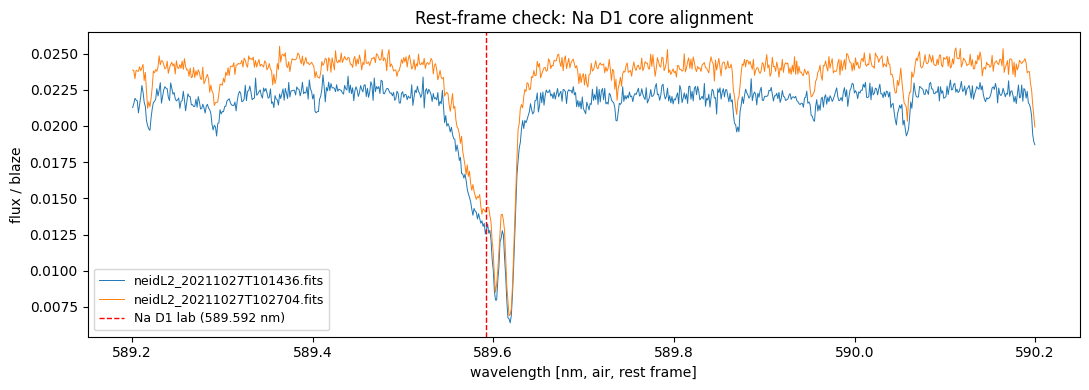

In [4]:
# --- deblaze + rest-frame shift for each exposure ---
NAD_LAB = 589.592   # Na D1 air rest wavelength [nm], sanity anchor

rest = []
for f in L2_FILES:
    print(os.path.basename(f))
    ods = deblaze_neid(f)
    w, fl, er, info = to_rest_frame(ods, f)
    rest.append((w, fl, er, os.path.basename(f)))

# sanity: Na D1 core should land on 589.592 nm after the shift, for both exposures
fig, ax = plt.subplots(figsize=(11, 4))
for w, fl, er, name in rest:
    m = (w > 589.2) & (w < 590.2)
    ax.plot(w[m], fl[m], lw=0.7, label=name)
ax.axvline(NAD_LAB, color='r', ls='--', lw=1, label='Na D1 lab (589.592 nm)')
ax.set_xlabel('wavelength [nm, air, rest frame]'); ax.set_ylabel('flux / blaze')
ax.set_title('Rest-frame check: Na D1 core alignment')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'restframe_check.png'), dpi=120, bbox_inches='tight'); plt.show()

## Step 3: cosmic-ray removal + continuum normalization

Model-independent (Splines, no template). Cosmic filter uses a rough median+max continuum first, then the continuum is re-fit on the cleaned spectrum and the spectrum normalized to 1.


[2026-07-18 21:09:36,507] [INFO] [utils:_init_num_threads:161]: NumExpr defaulting to 10 threads.


neidL2_20211027T101436.fits
  removed 4 cosmic-ray pixels; normalized (splines)
neidL2_20211027T102704.fits


/Users/wangxianyu/Program/Github/iSpec_v20230804/ispec/spectrum.py:877: RuntimeWarning: divide by zero encountered in scalar divide
  waveobs, flux, err = __interpolation(spectrum['waveobs'], spectrum['flux'], spectrum['err'], xaxis, bessel=False, zero_edges=zero_edges, frame=frame)
/Users/wangxianyu/Program/Github/iSpec_v20230804/ispec/spectrum.py:877: RuntimeWarning: invalid value encountered in scalar multiply
  waveobs, flux, err = __interpolation(spectrum['waveobs'], spectrum['flux'], spectrum['err'], xaxis, bessel=False, zero_edges=zero_edges, frame=frame)
/Users/wangxianyu/Program/Github/iSpec_v20230804/ispec/spectrum.py:877: RuntimeWarning: invalid value encountered in scalar divide
  waveobs, flux, err = __interpolation(spectrum['waveobs'], spectrum['flux'], spectrum['err'], xaxis, bessel=False, zero_edges=zero_edges, frame=frame)


  removed 6 cosmic-ray pixels; normalized (splines)


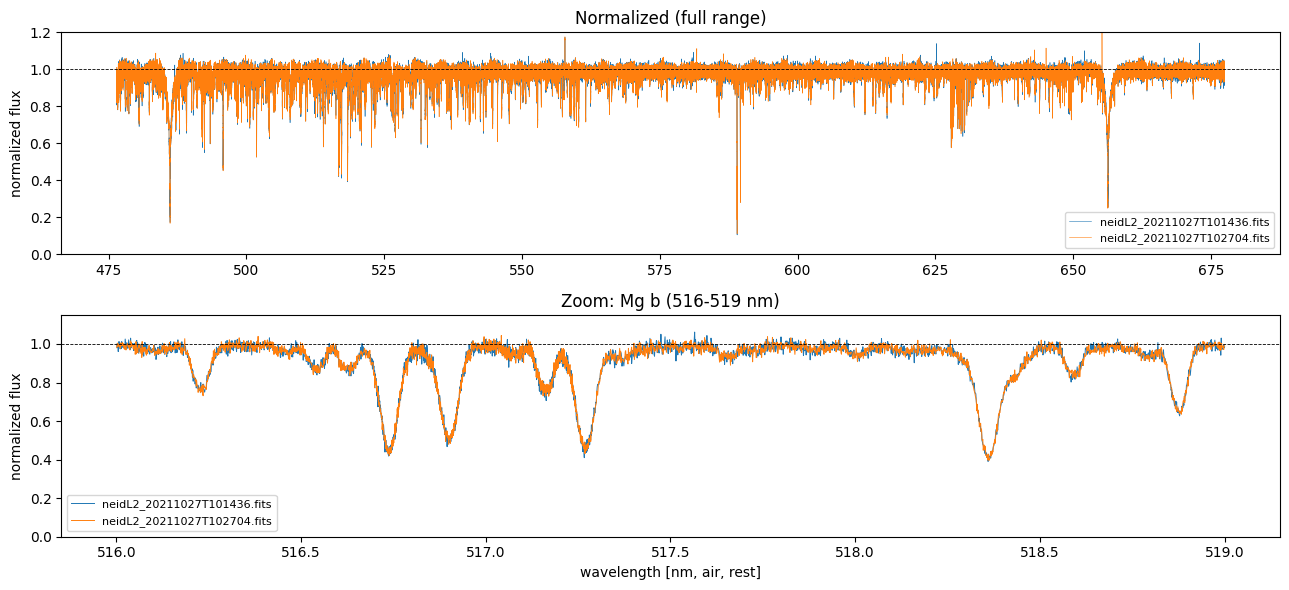

In [5]:
# --- clean + normalize each rest-frame exposure ---
norm_specs = []
for w, fl, er, name in rest:
    print(name)
    nspec, ncos = clean_and_normalize(w, fl, er, resolution=110000)
    norm_specs.append((nspec, name))

fig, ax = plt.subplots(2, 1, figsize=(13, 6))
for nspec, name in norm_specs:
    ax[0].plot(nspec['waveobs'], nspec['flux'], lw=0.4, label=name)
ax[0].axhline(1, color='k', lw=0.6, ls='--')
ax[0].set_ylim(0, 1.2); ax[0].set_ylabel('normalized flux')
ax[0].set_title('Normalized (full range)'); ax[0].legend(fontsize=8)
# zoom Mg b to check line depths agree between exposures
for nspec, name in norm_specs:
    m = (nspec['waveobs'] > 516) & (nspec['waveobs'] < 519)
    ax[1].plot(nspec['waveobs'][m], nspec['flux'][m], lw=0.7, label=name)
ax[1].axhline(1, color='k', lw=0.6, ls='--'); ax[1].set_ylim(0, 1.15)
ax[1].set_xlabel('wavelength [nm, air, rest]'); ax[1].set_ylabel('normalized flux')
ax[1].set_title('Zoom: Mg b (516-519 nm)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'normalize_check.png'), dpi=120, bbox_inches='tight'); plt.show()

## Step 4: coadd

Resample each normalized exposure onto a common grid with `ispec.resample_spectrum`, then combine with an inverse-variance weighted mean.


/Users/wangxianyu/Program/Github/NEID_iSpec/helper.py:250: RuntimeWarning: divide by zero encountered in divide
  w = np.where(np.isfinite(e) & (e > 0), 1.0 / e**2, 0.0)


  coadded 2 spectra -> 197472 px, 480.0-677.5 nm


/Users/wangxianyu/Program/Github/NEID_iSpec/helper.py:259: RuntimeWarning: Mean of empty slice
  np.nanmean(np.where(F != 0, F, np.nan), axis=0))


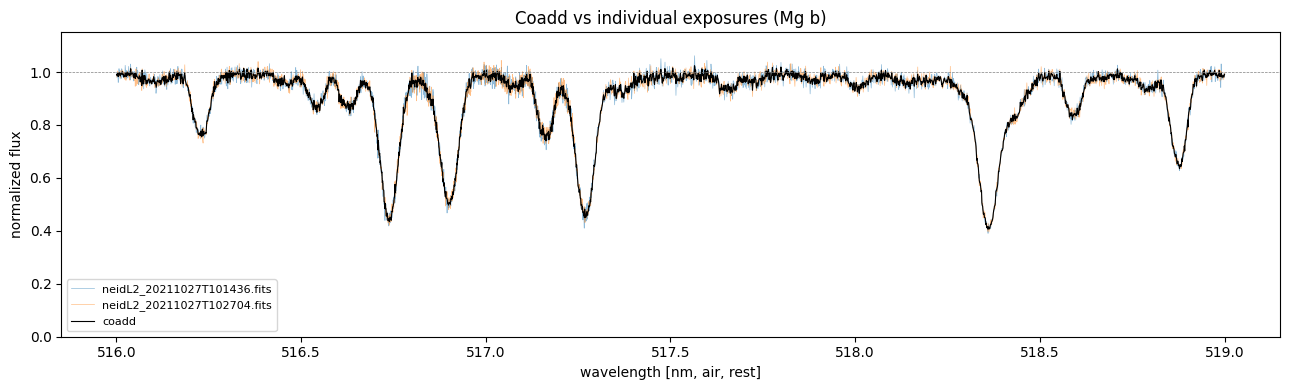

saved coadd_norm.txt


In [6]:
# --- coadd the normalized exposures ---
coadd = coadd_spectra(norm_specs)

fig, ax = plt.subplots(figsize=(13, 4))
for nspec, name in norm_specs:
    m = (nspec['waveobs'] > 516) & (nspec['waveobs'] < 519)
    ax.plot(nspec['waveobs'][m], nspec['flux'][m], lw=0.5, alpha=0.5, label=name)
m = (coadd['waveobs'] > 516) & (coadd['waveobs'] < 519)
ax.plot(coadd['waveobs'][m], coadd['flux'][m], 'k-', lw=0.8, label='coadd')
ax.axhline(1, color='gray', lw=0.5, ls='--'); ax.set_ylim(0, 1.15)
ax.set_xlabel('wavelength [nm, air, rest]'); ax.set_ylabel('normalized flux')
ax.set_title('Coadd vs individual exposures (Mg b)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'coadd_check.png'), dpi=120, bbox_inches='tight'); plt.show()

# save the coadd for the fitting step
_ispec = __import__('helper')._ispec()
_ispec.write_spectrum(coadd, os.path.join(DATA_DIR, 'coadd_norm.txt'))
print('saved coadd_norm.txt')

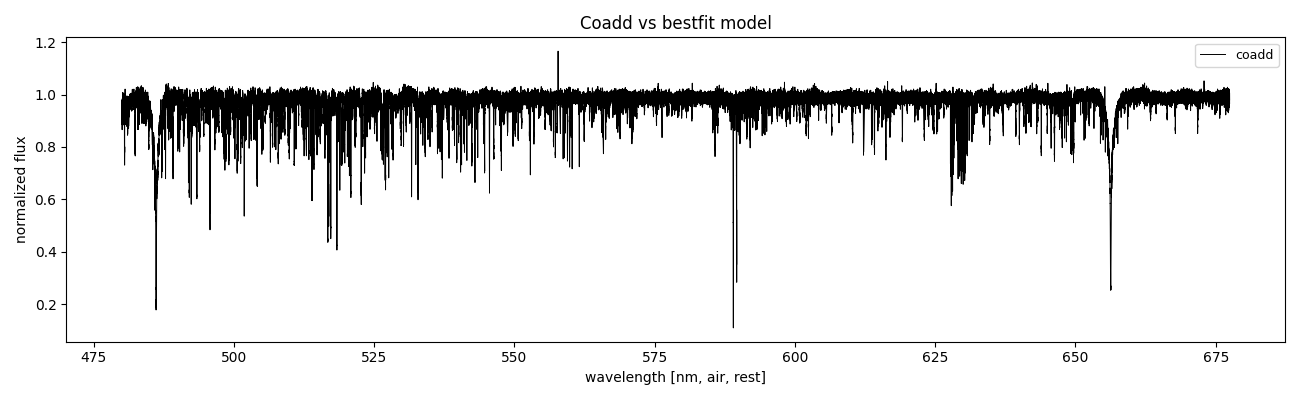

In [15]:
# /Users/wangxianyu/Program/Github/NEID_iSpec/output/bestfit_model.txt
%matplotlib widget

wavelengths_model, flux_model,_ = np.loadtxt(os.path.join(OUT_DIR, 'bestfit_model.txt'), unpack=True,skiprows=1)
wavelengths_coadd, flux_coadd,_ = np.loadtxt(os.path.join(DATA_DIR, 'coadd_norm.txt'), unpack=True, skiprows=1)
plt.figure(figsize=(13, 4))
plt.plot(wavelengths_coadd, flux_coadd, 'k-', lw=0.7, label='coadd')
# plt.plot(wavelengths_model, flux_model, 'r-', lw=0.7, label='bestfit model')
plt.xlabel('wavelength [nm, air, rest]'); plt.ylabel('normalized flux')
plt.title('Coadd vs bestfit model'); plt.legend(fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'coadd_vs_model.png'), dpi=120, bbox_inches='tight'); plt.show()